Топ-3 окон с максимальным phase_diff:


,window_file,phase_diff
0,window_4274.csv,12.348354
1,window_2630.csv,12.316886
2,window_1722.csv,12.309907


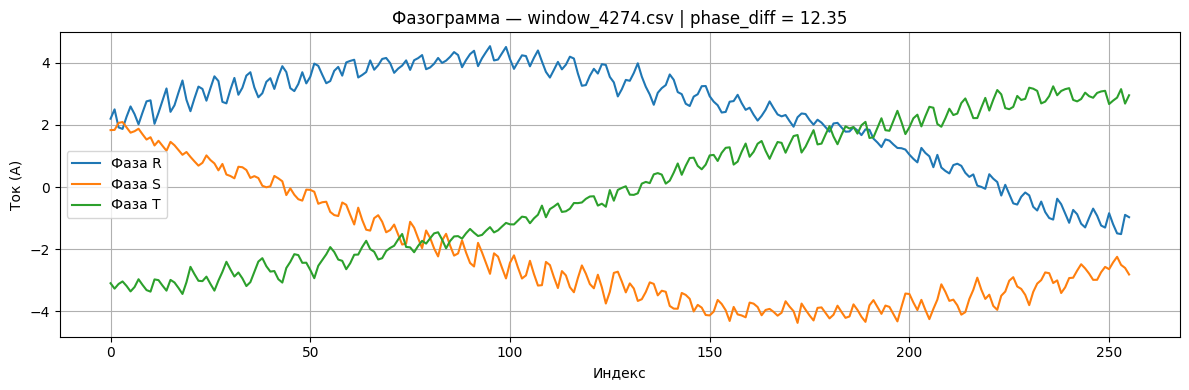

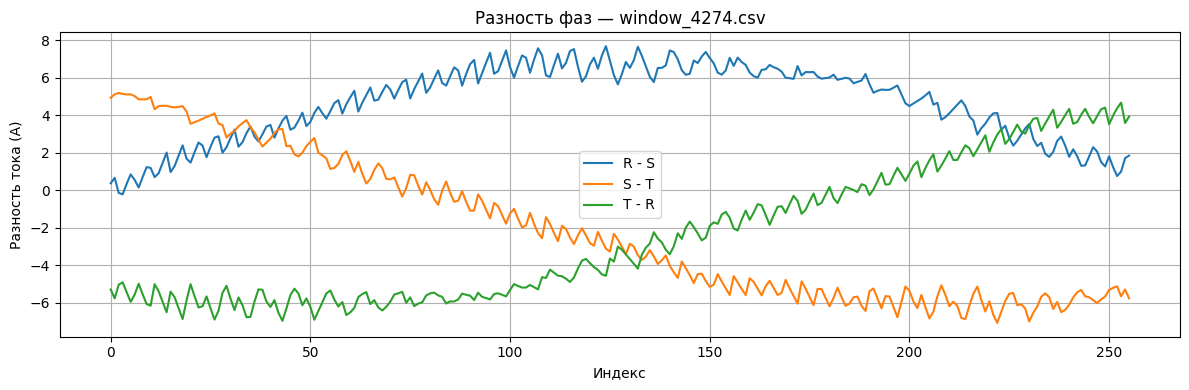

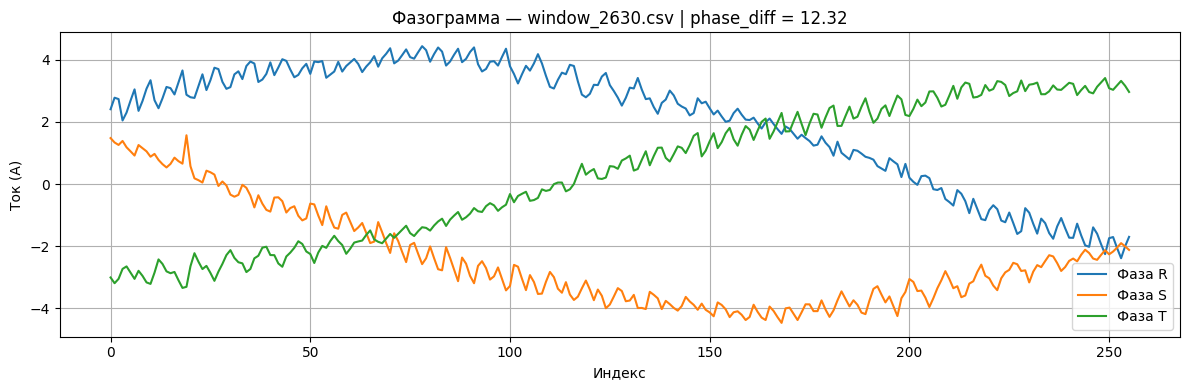

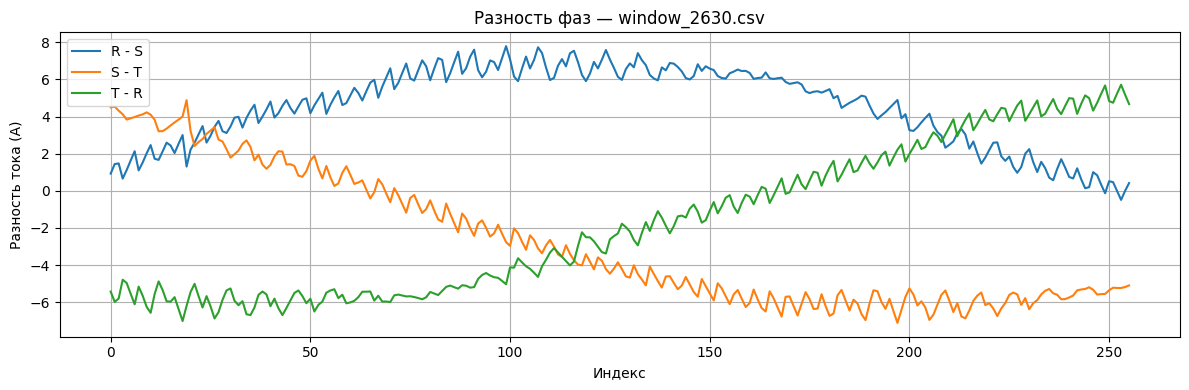

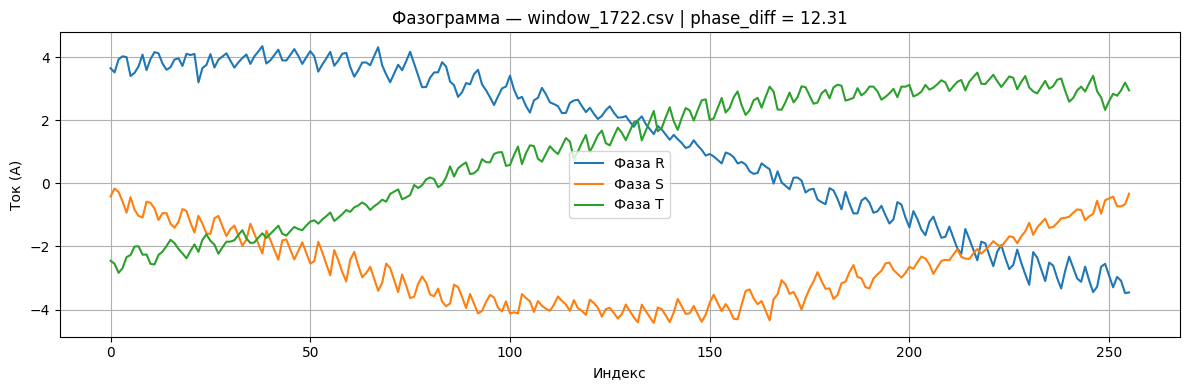

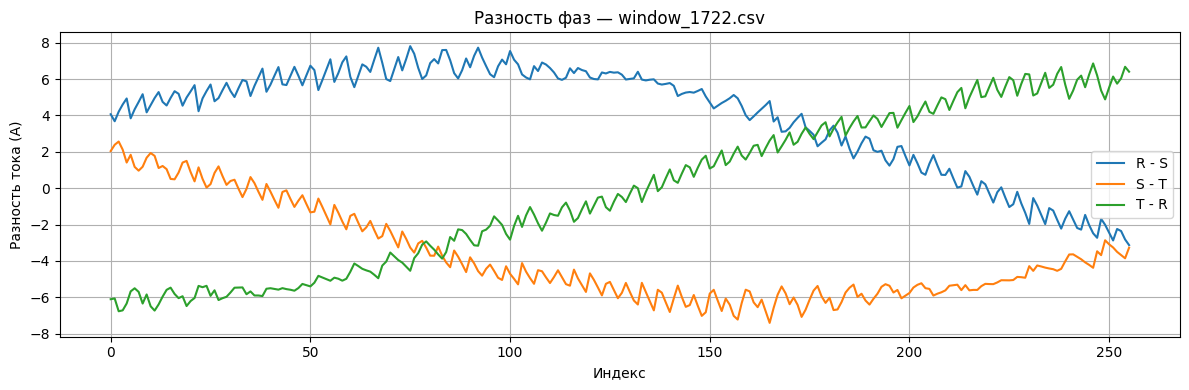

In [1]:
# 📓 Визуализация фазограмм и разностей фаз для топ-3 окон по phase_diff

import os
import pandas as pd
import matplotlib.pyplot as plt

# === Параметры ===
DATASET_PATH = "split_windows_256/5"  # Папка с окнами
PHASE_DIFF_THRESHOLD = 5.0  # Пороговое значение для phase_diff (если нужно фильтровать)
TOP_N = 3  # Сколько окон показать

# === Поиск аномальных окон ===
anomalies = []

for file in sorted(os.listdir(DATASET_PATH)):
    if not file.endswith(".csv"):
        continue
    try:
        file_path = os.path.join(DATASET_PATH, file)
        df = pd.read_csv(file_path)

        if not {"current_R", "current_S", "current_T"}.issubset(df.columns):
            continue

        phase_diff = (
            (df["current_R"] - df["current_S"]).abs().mean() +
            (df["current_S"] - df["current_T"]).abs().mean() +
            (df["current_T"] - df["current_R"]).abs().mean()
        )

        anomalies.append({
            "window_file": file,
            "phase_diff": phase_diff
        })

    except Exception as e:
        print(f"❌ Ошибка в файле {file_path}: {e}")

# === Формируем DataFrame с результатами ===
df_anomalies = pd.DataFrame(anomalies).sort_values(by="phase_diff", ascending=False)
df_top = df_anomalies.head(TOP_N).reset_index(drop=True)

print(f"Топ-{TOP_N} окон с максимальным phase_diff:")
display(df_top)

# === Визуализация фазограммы и разности фаз ===
for idx, row in df_top.iterrows():
    window_file = row["window_file"]
    file_path = os.path.join(DATASET_PATH, window_file)
    df_window = pd.read_csv(file_path)

    # Фазограмма
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"], label="Фаза R")
    plt.plot(df_window["current_S"], label="Фаза S")
    plt.plot(df_window["current_T"], label="Фаза T")
    plt.title(f"Фазограмма — {window_file} | phase_diff = {row['phase_diff']:.2f}")
    plt.xlabel("Индекс")
    plt.ylabel("Ток (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Разность фаз
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"] - df_window["current_S"], label="R - S")
    plt.plot(df_window["current_S"] - df_window["current_T"], label="S - T")
    plt.plot(df_window["current_T"] - df_window["current_R"], label="T - R")
    plt.title(f"Разность фаз — {window_file}")
    plt.xlabel("Индекс")
    plt.ylabel("Разность тока (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


Топ-3 окон с максимальным phase_diff:


,window_file,phase_diff
0,window_1064.csv,4.699255
1,window_970.csv,4.697934
2,window_972.csv,4.696490


Окно с минимальным phase_diff:


,window_file,phase_diff
0,window_1335.csv,4.631824


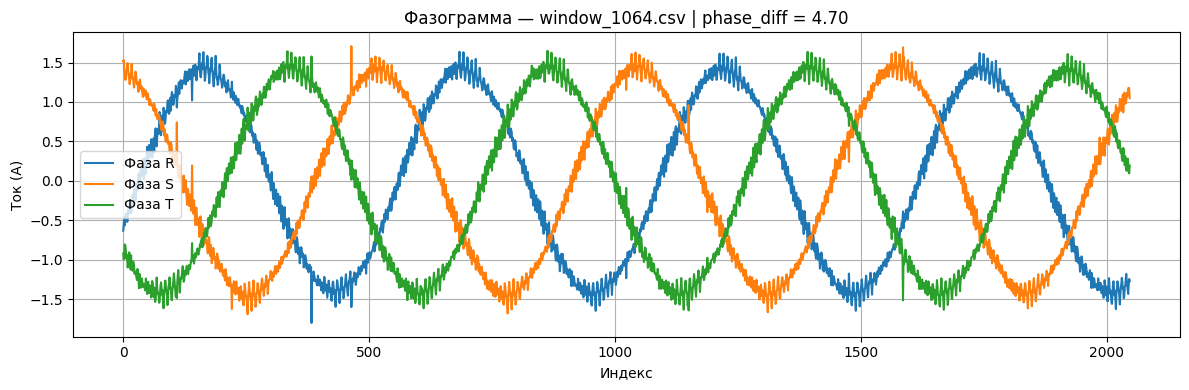

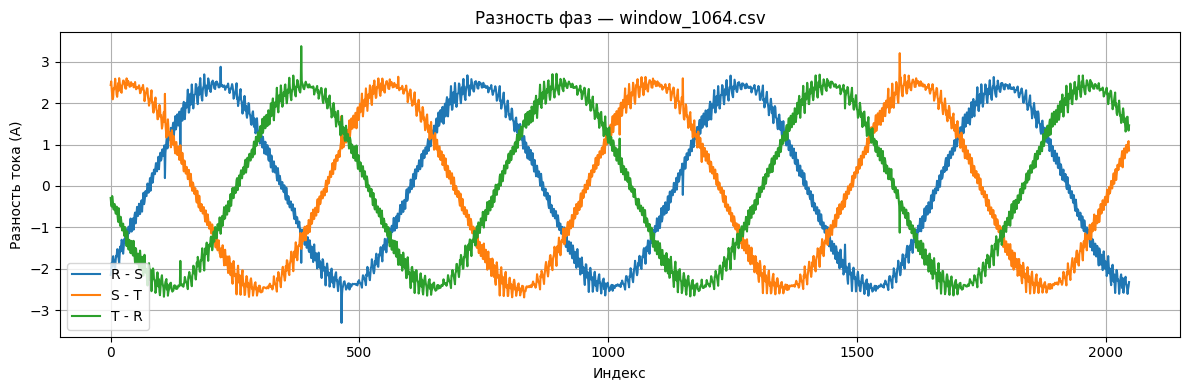

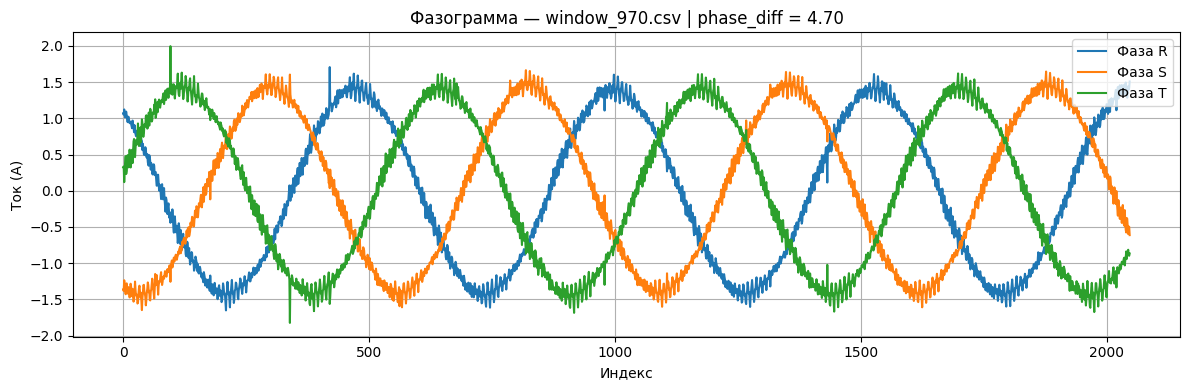

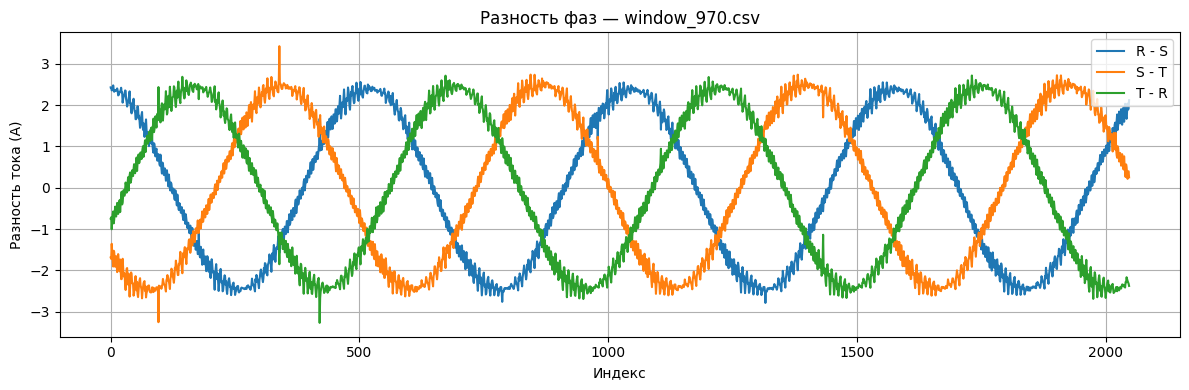

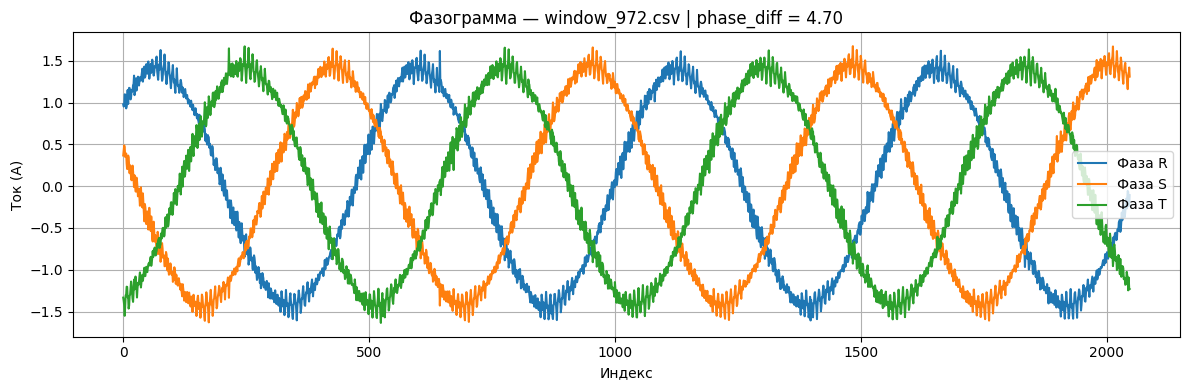

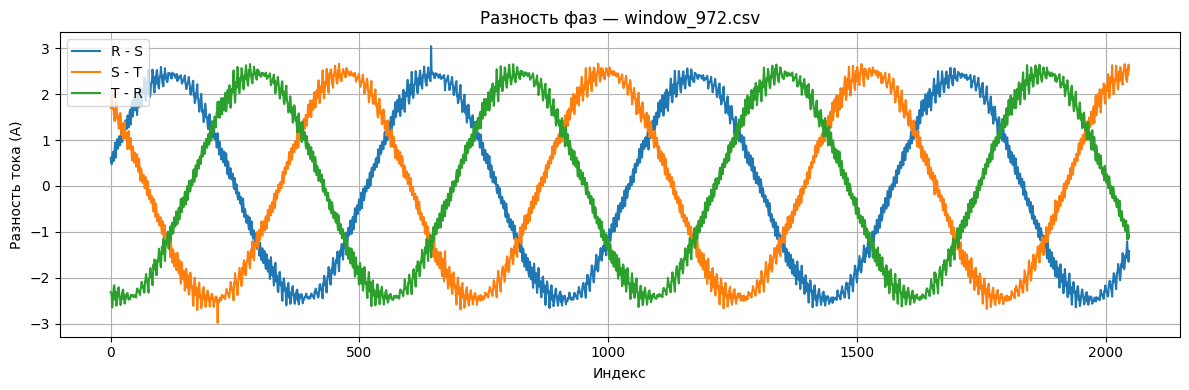

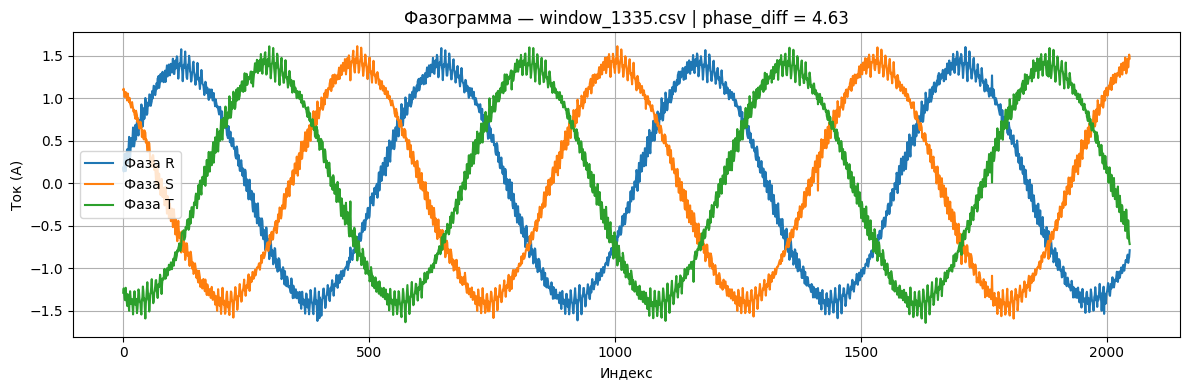

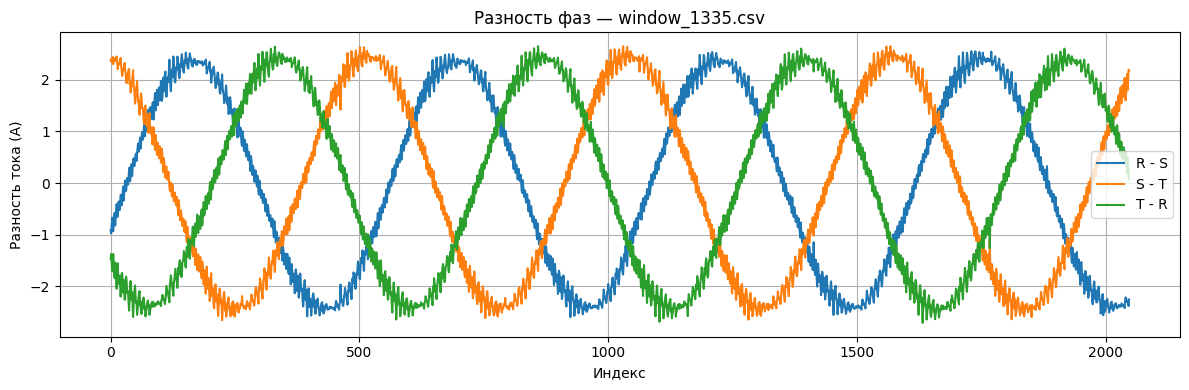

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# === Параметры ===
DATASET_PATH = "split_windows_2048/2"
TOP_N = 3  # Сколько аномальных окон показать

# === Сбор phase_diff по всем окнам ===
anomalies = []

for file in sorted(os.listdir(DATASET_PATH)):
    if not file.endswith(".csv"):
        continue
    try:
        file_path = os.path.join(DATASET_PATH, file)
        df = pd.read_csv(file_path)

        if not {"current_R", "current_S", "current_T"}.issubset(df.columns):
            continue

        phase_diff = (
            (df["current_R"] - df["current_S"]).abs().mean() +
            (df["current_S"] - df["current_T"]).abs().mean() +
            (df["current_T"] - df["current_R"]).abs().mean()
        )

        anomalies.append({
            "window_file": file,
            "phase_diff": phase_diff
        })

    except Exception as e:
        print(f"❌ Ошибка в файле {file_path}: {e}")

df_anomalies = pd.DataFrame(anomalies).sort_values(by="phase_diff", ascending=False)

# === Топ-N окон с максимальным phase_diff ===
df_top = df_anomalies.head(TOP_N).reset_index(drop=True)
print(f"Топ-{TOP_N} окон с максимальным phase_diff:")
display(df_top)

# === Окно с минимальным phase_diff ===
df_min = df_anomalies.tail(1).reset_index(drop=True)
print("Окно с минимальным phase_diff:")
display(df_min)

# === Функция для визуализации ===
def plot_window(file_name, phase_diff_value):
    file_path = os.path.join(DATASET_PATH, file_name)
    df_window = pd.read_csv(file_path)

    # Фазограмма
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"], label="Фаза R")
    plt.plot(df_window["current_S"], label="Фаза S")
    plt.plot(df_window["current_T"], label="Фаза T")
    plt.title(f"Фазограмма — {file_name} | phase_diff = {phase_diff_value:.2f}")
    plt.xlabel("Индекс")
    plt.ylabel("Ток (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Разность фаз
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"] - df_window["current_S"], label="R - S")
    plt.plot(df_window["current_S"] - df_window["current_T"], label="S - T")
    plt.plot(df_window["current_T"] - df_window["current_R"], label="T - R")
    plt.title(f"Разность фаз — {file_name}")
    plt.xlabel("Индекс")
    plt.ylabel("Разность тока (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Визуализация топ-аномальных окон ===
for idx, row in df_top.iterrows():
    plot_window(row["window_file"], row["phase_diff"])

# === Визуализация окна с минимальным phase_diff ===
row = df_min.iloc[0]
plot_window(row["window_file"], row["phase_diff"])


### Прогоняет все окна по метрике phase_diff во всех папках

🔍 Найдено файлов для анализа: 750


Анализ окон: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 750/750 [00:04<00:00, 171.58it/s]


📊 Топ-3 окон с максимальным phase_diff:


,window_file,phase_diff
0,split_windows_2048/31\window_000.csv,NaN
1,split_windows_2048/31\window_001.csv,NaN
2,split_windows_2048/31\window_002.csv,NaN



✅ Окно с минимальным phase_diff:


,window_file,phase_diff
0,split_windows_2048/31\window_749.csv,NaN


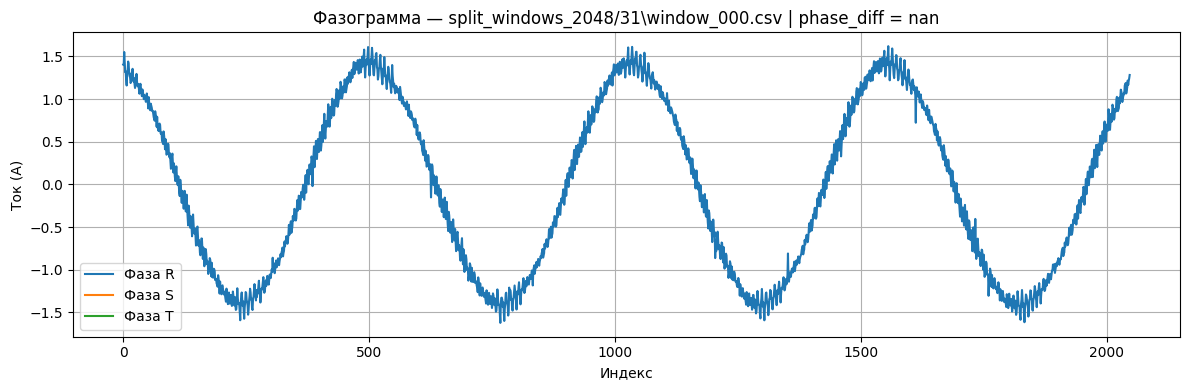

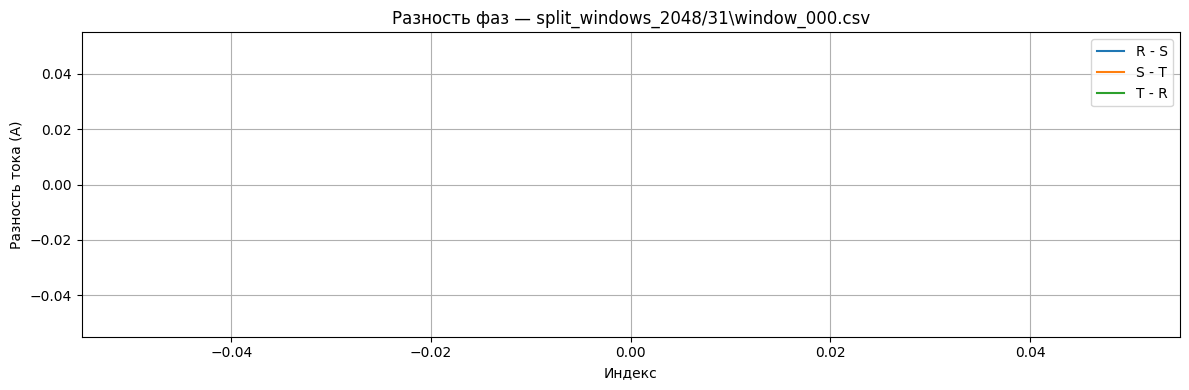

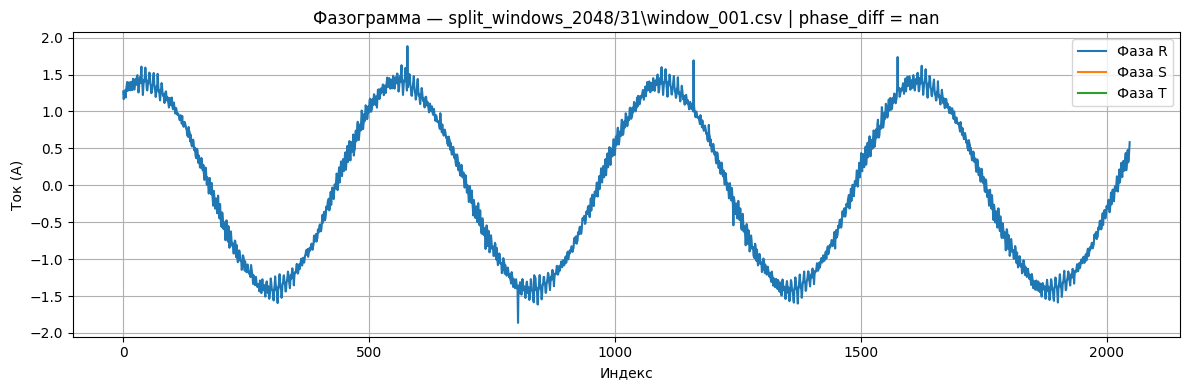

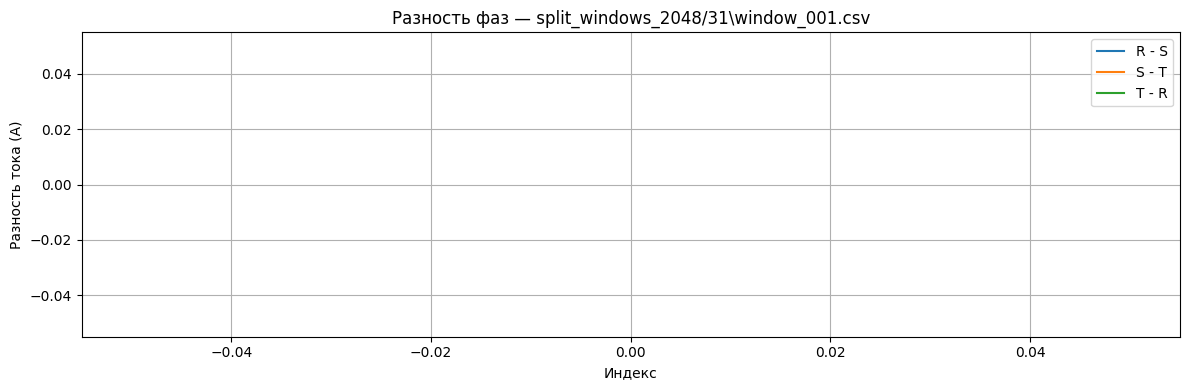

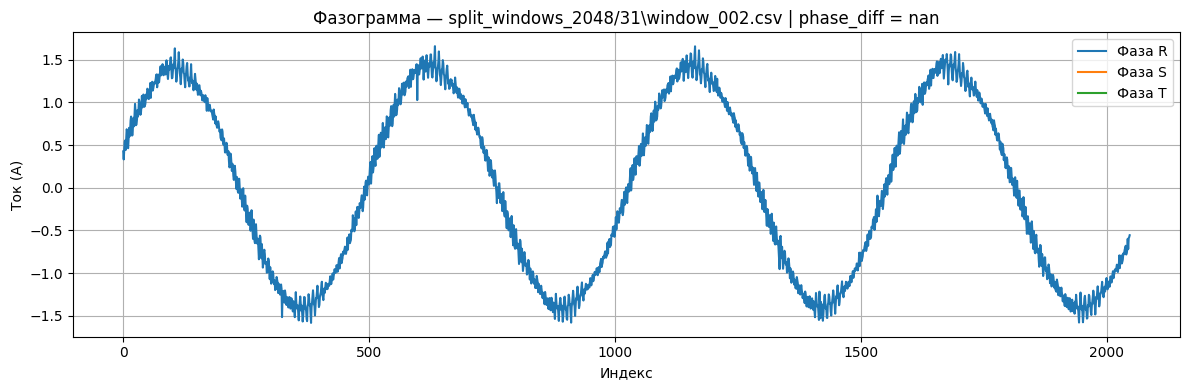

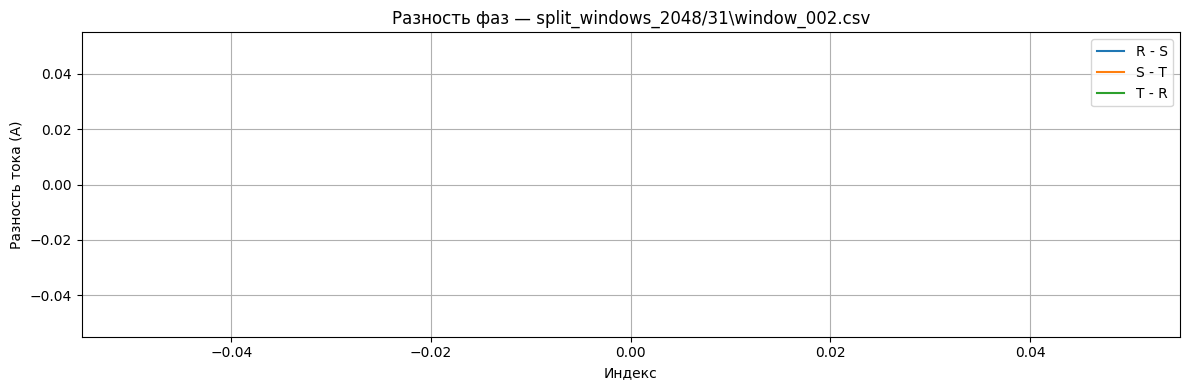

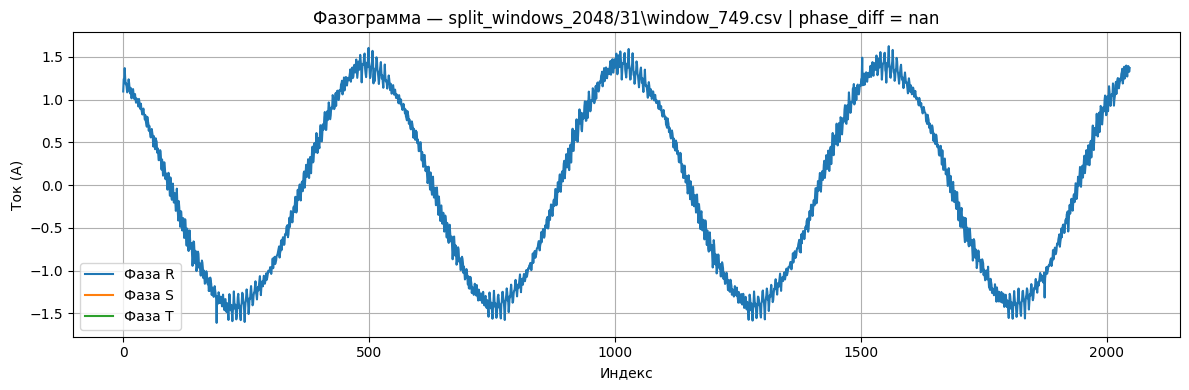

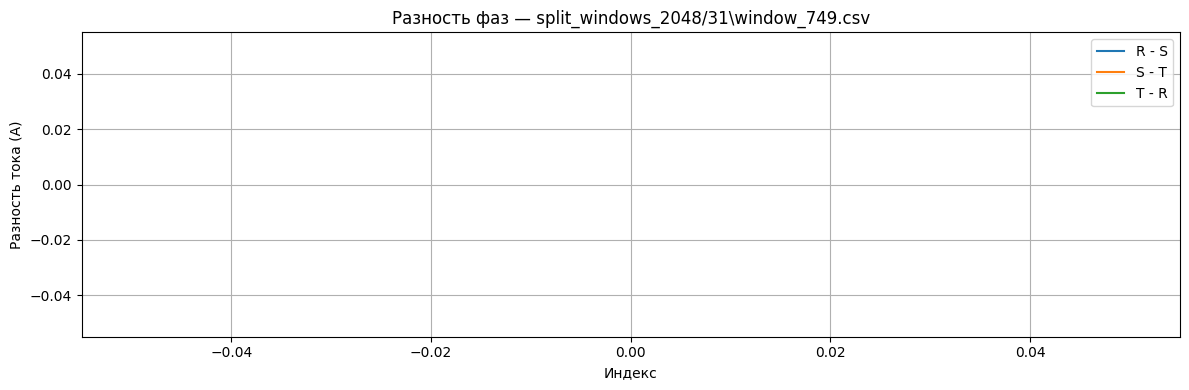

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm  # Для прогресса

# === Параметры ===
BASE_FOLDER = "split_windows_2048/31"  # Папка с окнами (и подпапками)
TOP_N = 3  # Сколько аномальных окон показать

# === Сбор phase_diff по всем окнам ===
anomalies = []

# Собираем все пути ко всем .csv файлам в подпапках
all_window_files = []
for root, dirs, files in os.walk(BASE_FOLDER):
    for file in files:
        if file.endswith(".csv"):
            all_window_files.append(os.path.join(root, file))

print(f"🔍 Найдено файлов для анализа: {len(all_window_files)}")

for file_path in tqdm(all_window_files, desc="Анализ окон"):
    try:
        df = pd.read_csv(file_path)

        if not {"current_R", "current_S", "current_T"}.issubset(df.columns):
            continue

        phase_diff = (
            (df["current_R"] - df["current_S"]).abs().mean() +
            (df["current_S"] - df["current_T"]).abs().mean() +
            (df["current_T"] - df["current_R"]).abs().mean()
        )

        anomalies.append({
            "window_file": file_path,
            "phase_diff": phase_diff
        })

    except Exception as e:
        print(f"❌ Ошибка в файле {file_path}: {e}")

df_anomalies = pd.DataFrame(anomalies).sort_values(by="phase_diff", ascending=False)

# === Топ-N окон с максимальным phase_diff ===
df_top = df_anomalies.head(TOP_N).reset_index(drop=True)
print(f"\n📊 Топ-{TOP_N} окон с максимальным phase_diff:")
display(df_top)

# === Окно с минимальным phase_diff ===
df_min = df_anomalies.tail(1).reset_index(drop=True)
print("\n✅ Окно с минимальным phase_diff:")
display(df_min)

# === Функция для визуализации ===
def plot_window(file_path, phase_diff_value):
    df_window = pd.read_csv(file_path)

    # Фазограмма
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"], label="Фаза R")
    plt.plot(df_window["current_S"], label="Фаза S")
    plt.plot(df_window["current_T"], label="Фаза T")
    plt.title(f"Фазограмма — {file_path} | phase_diff = {phase_diff_value:.2f}")
    plt.xlabel("Индекс")
    plt.ylabel("Ток (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Разность фаз
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"] - df_window["current_S"], label="R - S")
    plt.plot(df_window["current_S"] - df_window["current_T"], label="S - T")
    plt.plot(df_window["current_T"] - df_window["current_R"], label="T - R")
    plt.title(f"Разность фаз — {file_path}")
    plt.xlabel("Индекс")
    plt.ylabel("Разность тока (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Визуализация топ-аномальных окон ===
for idx, row in df_top.iterrows():
    plot_window(row["window_file"], row["phase_diff"])

# === Визуализация окна с минимальным phase_diff ===
row = df_min.iloc[0]
plot_window(row["window_file"], row["phase_diff"])


🔍 Найдено файлов для анализа (с учётом исключений): 330482


Анализ окон: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 330482/330482 [26:00<00:00, 211.76it/s]



📊 Топ-3 окон с максимальным phase_diff:


,window_file,phase_diff
0,split_windows_256\30\window_489.csv,4.840256
1,split_windows_256\6\window_016.csv,4.834801
2,split_windows_256\12\window_355.csv,4.831020



✅ Окно с минимальным phase_diff:


,window_file,phase_diff
0,split_windows_256\29\window_10345.csv,4.512426


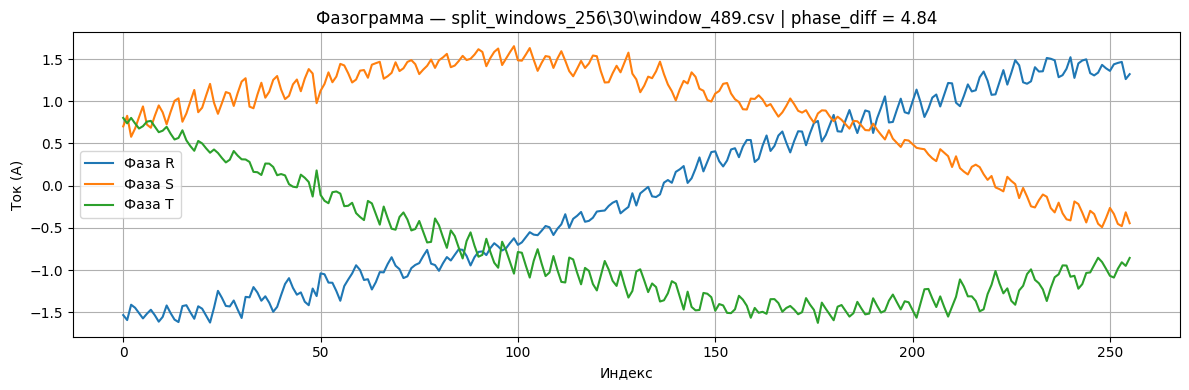

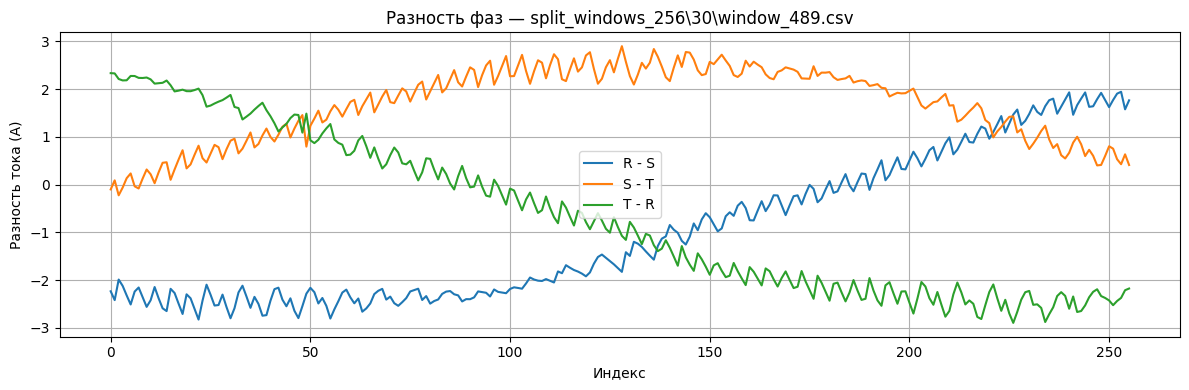

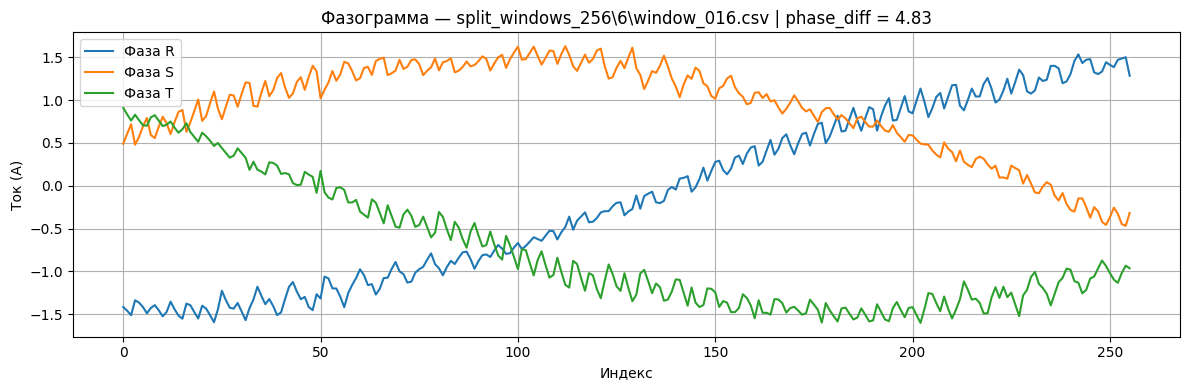

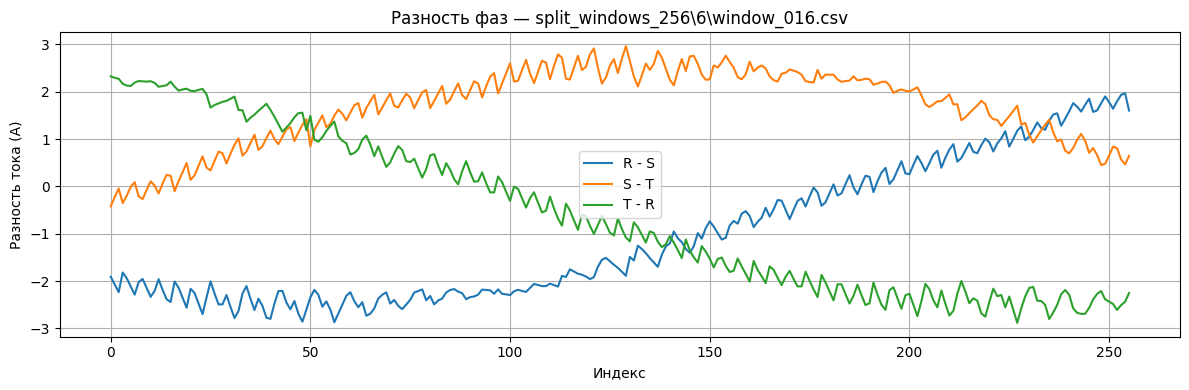

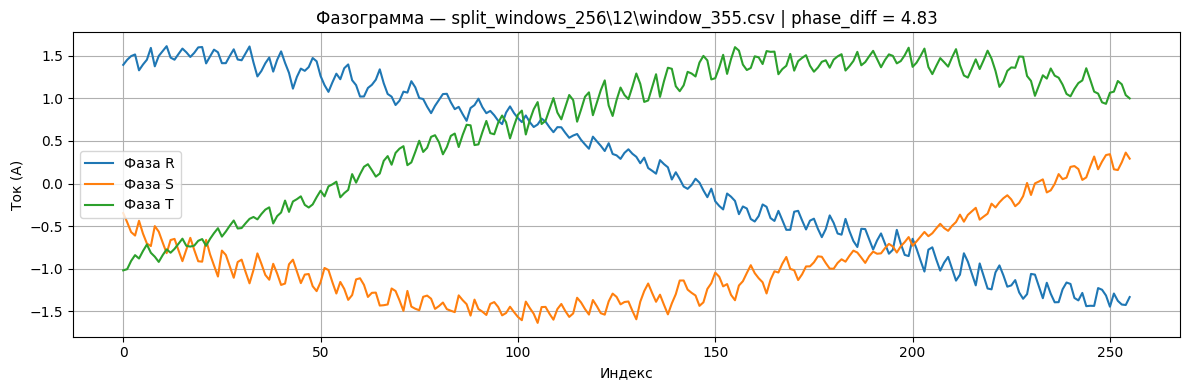

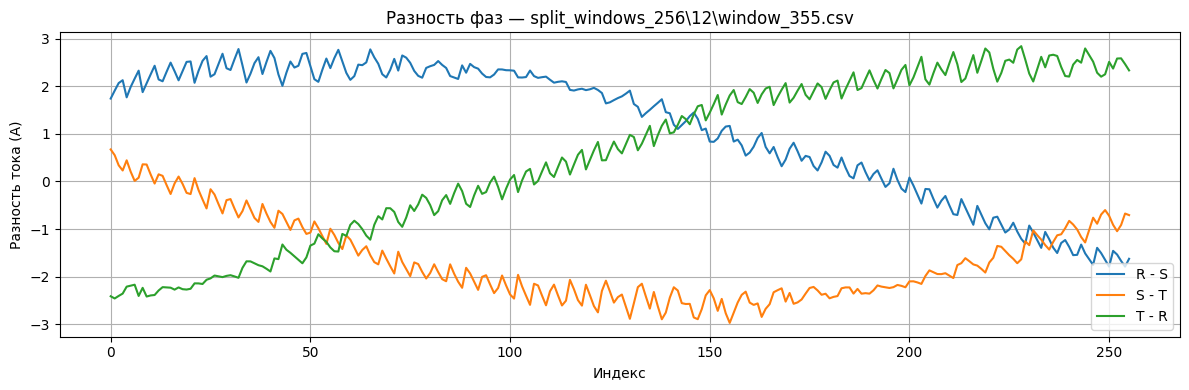

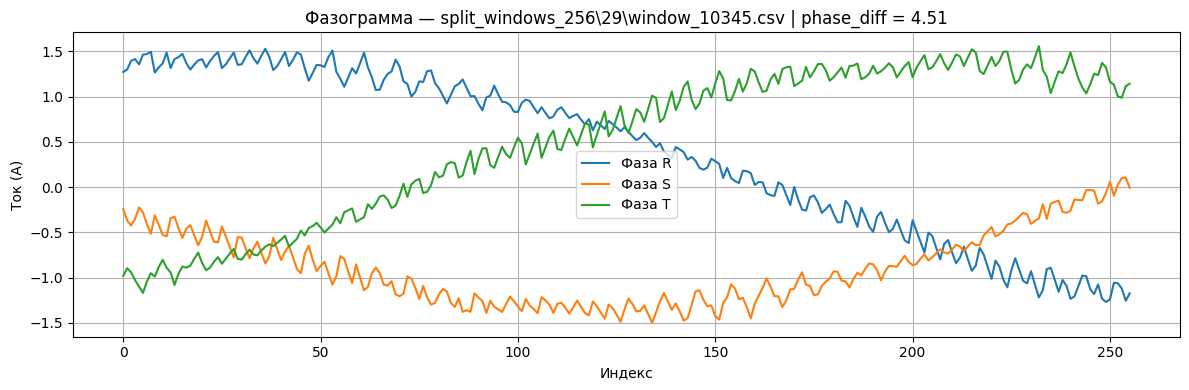

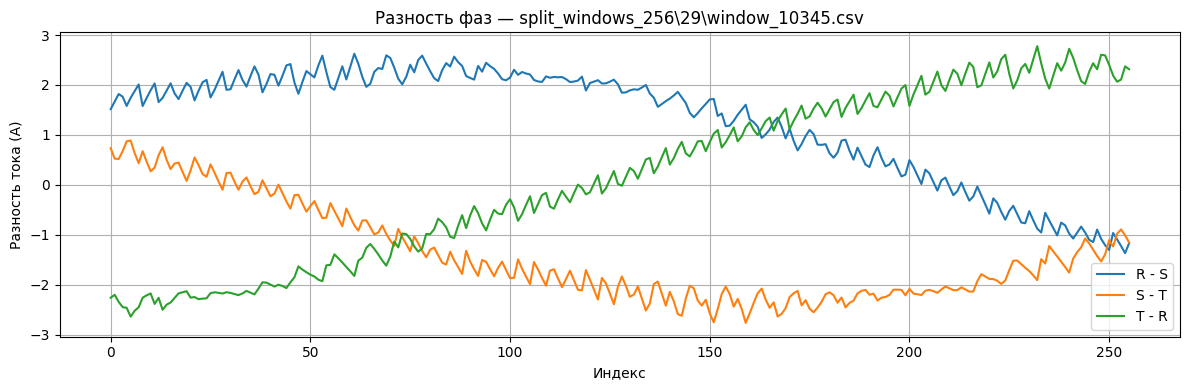

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# === Параметры ===
BASE_FOLDER = "split_windows_256"         # Папка с подпапками
EXCLUDE_DATASETS = {"11", "25", "19", "21", "17", "15", "23", "27", "31"}             # Исключаемые датасеты (укажи номера строкой, например: {"31", "7"})
TOP_N = 3                                   # Сколько аномалий показать

# === Сбор phase_diff по всем окнам ===
anomalies = []
all_window_files = []

# Проход по всем подпапкам и файлам
for root, dirs, files in os.walk(BASE_FOLDER):
    parts = root.split(os.sep)
    if any(part in EXCLUDE_DATASETS for part in parts):
        continue  # Пропускаем исключённые

    for file in files:
        if file.endswith(".csv"):
            all_window_files.append(os.path.join(root, file))

print(f"🔍 Найдено файлов для анализа (с учётом исключений): {len(all_window_files)}")

# Обработка каждого окна
for file_path in tqdm(all_window_files, desc="Анализ окон"):
    try:
        df = pd.read_csv(file_path)

        if not {"current_R", "current_S", "current_T"}.issubset(df.columns):
            continue

        phase_diff = (
            (df["current_R"] - df["current_S"]).abs().mean() +
            (df["current_S"] - df["current_T"]).abs().mean() +
            (df["current_T"] - df["current_R"]).abs().mean()
        )

        anomalies.append({
            "window_file": file_path,
            "phase_diff": phase_diff
        })

    except Exception as e:
        print(f"❌ Ошибка в файле {file_path}: {e}")

# === Анализ результатов ===
df_anomalies = pd.DataFrame(anomalies).sort_values(by="phase_diff", ascending=False)

# Топ аномальных окон
df_top = df_anomalies.head(TOP_N).reset_index(drop=True)
print(f"\n📊 Топ-{TOP_N} окон с максимальным phase_diff:")
display(df_top)

# Минимально аномальное окно
df_min = df_anomalies.tail(1).reset_index(drop=True)
print("\n✅ Окно с минимальным phase_diff:")
display(df_min)

# === Визуализация ===
def plot_window(file_path, phase_diff_value):
    df_window = pd.read_csv(file_path)

    # Фазограмма
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"], label="Фаза R")
    plt.plot(df_window["current_S"], label="Фаза S")
    plt.plot(df_window["current_T"], label="Фаза T")
    plt.title(f"Фазограмма — {file_path} | phase_diff = {phase_diff_value:.2f}")
    plt.xlabel("Индекс")
    plt.ylabel("Ток (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Разность фаз
    plt.figure(figsize=(12, 4))
    plt.plot(df_window["current_R"] - df_window["current_S"], label="R - S")
    plt.plot(df_window["current_S"] - df_window["current_T"], label="S - T")
    plt.plot(df_window["current_T"] - df_window["current_R"], label="T - R")
    plt.title(f"Разность фаз — {file_path}")
    plt.xlabel("Индекс")
    plt.ylabel("Разность тока (А)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Визуализация
for _, row in df_top.iterrows():
    plot_window(row["window_file"], row["phase_diff"])

plot_window(df_min.iloc[0]["window_file"], df_min.iloc[0]["phase_diff"])
